In [132]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("../data/paysim_data.csv")
df.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


Nuevamente revisamos si existen datos nulos

In [111]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Verificamos si hay datos duplicados

In [112]:
df.duplicated().sum()

0

Reviso que no existan transacciones negativas o valores no numericos


In [113]:
cols = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "isFraud"]

for i in cols:
    print(f"Registros con {i} < 0: ", (df[i] < 0).sum())
    print(f"Cuantos datos no numericos tiene {i}: ", df[i].isna().sum())

Registros con amount < 0:  0
Cuantos datos no numericos tiene amount:  0
Registros con oldbalanceOrg < 0:  0
Cuantos datos no numericos tiene oldbalanceOrg:  0
Registros con newbalanceOrig < 0:  0
Cuantos datos no numericos tiene newbalanceOrig:  0
Registros con oldbalanceDest < 0:  0
Cuantos datos no numericos tiene oldbalanceDest:  0
Registros con newbalanceDest < 0:  0
Cuantos datos no numericos tiene newbalanceDest:  0
Registros con isFraud < 0:  0
Cuantos datos no numericos tiene isFraud:  0


No hay filas identicas en el dataset. Pero, se puede esperar que, mas de un cliente haya realizado mas de una transacción.

Revisamos si no existen tipos de datos mal escritos queafecten conteo de transacciones por tipo 

In [114]:
transacciones_por_tipo = df.groupby("type").size()
print(transacciones_por_tipo)

total_transacciones = transacciones_por_tipo.sum()

print("Suma por tipo:", total_transacciones)
print("Total de filas:", len(df))
print("¿Son iguales?", len(df) == total_transacciones)





type
CASH_IN     1399284
CASH_OUT    2237500
DEBIT         41432
PAYMENT     2151495
TRANSFER     532909
dtype: int64
Suma por tipo: 6362620
Total de filas: 6362620
¿Son iguales? True


Vemos que no hay datos de tipos de transacción perdidos. Concluyo que los campos requiridos para el modelo estan limpios.

Visualizacón de porcentaje por tipo de transacción

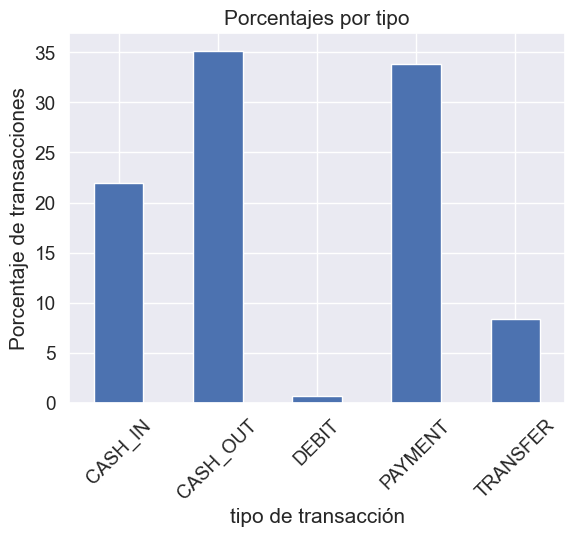

In [115]:
porcentaje_tipo = round((transacciones_por_tipo/total_transacciones)*100, 2)
porcentaje_tipo.plot(kind="bar")
plt.title("Porcentajes por tipo")
plt.xlabel("tipo de transacción")
plt.ylabel("Porcentaje de transacciones")
plt.xticks(rotation = 45)
plt.show()


Porcentajes de desbalance de clase

In [116]:
conteo_fraudes = df.groupby("isFraud").size()

porcentaje_fraudes = round((conteo_fraudes/total_transacciones) * 100, 2)
print(porcentaje_fraudes)

isFraud
0    99.87
1     0.13
dtype: float64


In [134]:
df.groupby("type")["isFraud"].sum()

type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64

Ahora revisare si los montos que esten por arriba del promedio o de la mediana son fraudes

In [118]:
amount_promedio = df["amount"].mean()
amount_mediana = df["amount"].median()

print("El promedio de amount es, ", amount_promedio)
print("La mediana de amount es, ", amount_mediana)

El promedio de amount es,  179861.90354913071
La mediana de amount es,  74871.94


Tanto el promedio como la mediana son muy diferentes entre si, lo cual refuerza que existen outliers debido a que exsiten transacciones con montos muy grandes que sesgan el promedio. Ahora verificaré cuantos datos que esten pro encima del promedio del amount son fraude.

In [119]:
df["monto_mayor_promedio"] = (df["amount"] > amount_promedio).astype(int)
df["monto_mayor_mediana"] = (df["amount"] > amount_mediana).astype(int)

df.groupby("monto_mayor_promedio")["isFraud"].agg(
    total_transacciones="count",
    total_fraudes="sum",
    tasa_fraude="mean"
)

,total_transacciones,total_fraudes,tasa_fraude
monto_mayor_promedio,,,
0,4486224,2611,0.000582
1,1876396,5602,0.002986


En la columna monto_mayor_promedio 0 indica que transacciones son igual o estan por debajo el promedio y 1 indica cuales estan por arriba del promedio del monto.

Ahora veamos que pasa con la mediana

In [120]:
df.groupby("monto_mayor_mediana")["isFraud"].agg(
    total_transacciones="count",
    total_fraudes="sum",
    tasa_fraude="mean"
)

,total_transacciones,total_fraudes,tasa_fraude
monto_mayor_mediana,,,
0,3181310,1406,0.000442
1,3181310,6807,0.002140


# Preparando datos para Machine Learning

Mediante One Hot Encoding sobre la columna type del dataset, creare las columnas binarias categoricas para que el modelo aprenda en que tipo de transacciones exsiten fraude. Anteriormente, vimos que los tipos de TRANSFER y CASH_OUT contiene el total de los fraudes registrados en el dataset. 

In [121]:
types = ["TRANSFER", "PAYMENT", "CASH_OUT", "CASH_IN", "DEBIT"]

for i in types:
    df[f"type_{i}"] = np.where(df["type"] == i, 1, 0)
    
df = df.drop("type", axis = 1)

df

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,monto_mayor_promedio,monto_mayor_mediana,type_TRANSFER,type_PAYMENT,type_CASH_OUT,type_CASH_IN,type_DEBIT
0,1,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0,0,0,0,1,0,0,0
1,1,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0,0,0,0,1,0,0,0
2,1,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0,0,0,1,0,0,0,0
3,1,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0,0,0,0,0,1,0,0
4,1,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0,1,1,0,0,1,0,0
6362616,743,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0,1,1,1,0,0,0,0
6362617,743,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0,1,1,0,0,1,0,0
6362618,743,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0,1,1,1,0,0,0,0


In [142]:
df["origin_balance_change"] = round((df["oldbalanceOrg"] - df["newbalanceOrig"]), 2)

df["dest_balance_change"] = (df["newbalanceDest"] - df["oldbalanceDest"])

df["orig_error"] = (df["amount"] -(df["oldbalanceOrg"] - df["newbalanceOrig"]))

df["dest_error"] = (df["amount"] -(df["newbalanceDest"] - df["oldbalanceDest"]))

df["orig_vacio"] = (df["newbalanceOrig"] == 0).astype(int)

df["dest_vacio"] = (df["oldbalanceDest"] == 0).astype(int)

df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,origin_balance_change,dest_balance_change,orig_error,dest_error,orig_vacio,dest_vacio
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0,9839.64,0.00,-1.455192e-11,9.839640e+03,0,1
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0,1864.28,0.00,1.136868e-12,1.864280e+03,0,1
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0,181.00,0.00,0.000000e+00,1.810000e+02,1,1
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0,181.00,-21182.00,0.000000e+00,2.136300e+04,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0,11668.14,0.00,0.000000e+00,1.166814e+04,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0,339682.13,339682.13,0.000000e+00,0.000000e+00,1,1
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0,6311409.28,0.00,0.000000e+00,6.311409e+06,1,1
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0,6311409.28,6311409.27,0.000000e+00,1.000000e-02,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0,850002.52,0.00,0.000000e+00,8.500025e+05,1,1


In [143]:
nuevas_variables = [
    "origin_balance_change",
    "dest_balance_change",
    "orig_error",
    "dest_error",
    "orig_vacio",
    "dest_vacio",
]

df[nuevas_variables].describe()

,origin_balance_change,dest_balance_change,orig_error,dest_error,orig_vacio,dest_vacio
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,-2.123056e+04,1.242947e+05,2.010925e+05,5.556717e+04,5.673081e-01,4.250431e-01
std,1.466433e+05,8.129391e+05,6.066505e+05,4.415288e+05,4.954489e-01,4.943496e-01
min,-1.915268e+06,-1.306083e+07,-1.000000e-02,-7.588573e+07,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,2.954230e+03,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00,6.867726e+04,3.500490e+03,1.000000e+00,0.000000e+00
75%,1.015044e+04,1.491054e+05,2.496411e+05,2.935305e+04,1.000000e+00,1.000000e+00
max,1.000000e+07,1.056878e+08,9.244552e+07,1.319123e+07,1.000000e+00,1.000000e+00


Ahora verificamos correlaciones 

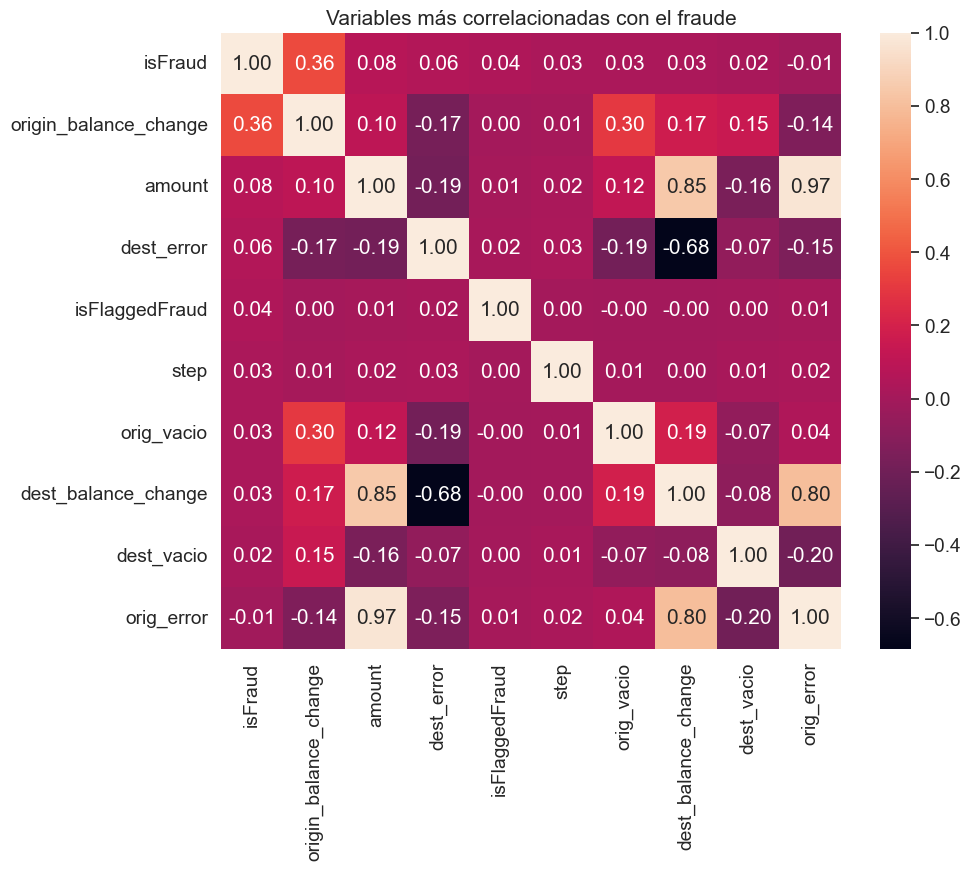

In [167]:
corrmat = df.corr(numeric_only=True)

top_vars = (corrmat["isFraud"].abs().sort_values(ascending=False).head(10).index)

plt.figure(figsize=(10,8))

sns.heatmap(df[top_vars].corr(), annot=True, fmt=".2f")

plt.title("Variables más correlacionadas con el fraude")
plt.show()